In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load dataset
df = pd.read_csv("ecommerce_sales.csv")


In [3]:
df.shape

(34500, 17)

In [4]:
df.head(20)

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male
5,O100005,C15191,P214062,Beauty,53.91,0.10,2,Credit Card,2024-04-14,5,South,No,97.04,6.32,37.35,35,Female
6,O100006,C13772,P201363,Electronics,266.50,0.00,1,PayPal,2025-05-20,5,East,No,266.50,9.10,22.88,49,Male
7,O100007,C13092,P216691,Beauty,9.98,0.00,1,Credit Card,2023-09-14,4,West,No,9.98,4.51,-0.02,66,Other
8,O100008,C15734,P202751,Fashion,6.61,0.05,1,Debit Card,2023-10-23,6,West,No,6.28,3.43,-1.23,37,Female
9,O100009,C16265,P207782,Grocery,10.91,0.00,1,Credit Card,2023-10-31,6,South,No,10.91,2.76,-1.89,56,Male


In [5]:
df.columns

Index(['order_id', 'customer_id', 'product_id', 'category', 'price',
       'discount', 'quantity', 'payment_method', 'order_date',
       'delivery_time_days', 'region', 'returned', 'total_amount',
       'shipping_cost', 'profit_margin', 'customer_age', 'customer_gender'],
      dtype='object')

In [6]:
# list(df.columns)    # Convert to list

In [7]:
len(df.columns)     # Count columns     # df.shape[1]  # Number of columns

17

In [8]:
df.describe()

,price,discount,quantity,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age
count,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000,34500.000000
mean,119.391632,0.049291,1.490725,4.814203,170.008494,6.152120,28.116505,43.474377
std,195.620477,0.069894,0.932270,1.242141,357.503014,2.389539,53.352947,14.980682
min,1.010000,0.000000,1.000000,3.000000,0.820000,0.000000,-6.200000,18.000000
25%,16.690000,0.000000,1.000000,4.000000,19.710000,4.420000,1.500000,31.000000
50%,45.660000,0.000000,1.000000,5.000000,56.820000,6.090000,10.550000,43.000000
75%,130.950000,0.100000,2.000000,6.000000,168.530000,7.830000,33.132500,56.000000
max,2930.470000,0.300000,5.000000,13.000000,12931.800000,15.650000,1536.170000,69.000000


In [9]:
df.isnull().sum()

order_id              0
customer_id           0
product_id            0
category              0
price                 0
discount              0
quantity              0
payment_method        0
order_date            0
delivery_time_days    0
region                0
returned              0
total_amount          0
shipping_cost         0
profit_margin         0
customer_age          0
customer_gender       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#df.dtypes

In [12]:
# change column name
df.rename(columns={"delivery_time_days": "delivery_time"}, inplace=True)   # single column name

In [13]:
# change multiple column name
df.rename(columns={
    "customer_age": "age",
    "customer_gender": "gender"
}, inplace=True)

In [14]:
df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34500 entries, 0 to 34499
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        34500 non-null  object 
 1   customer_id     34500 non-null  object 
 2   product_id      34500 non-null  object 
 3   category        34500 non-null  object 
 4   price           34500 non-null  float64
 5   discount        34500 non-null  float64
 6   quantity        34500 non-null  int64  
 7   payment_method  34500 non-null  object 
 8   order_date      34500 non-null  object 
 9   delivery_time   34500 non-null  int64  
 10  region          34500 non-null  object 
 11  returned        34500 non-null  object 
 12  total_amount    34500 non-null  float64
 13  shipping_cost   34500 non-null  float64
 14  profit_margin   34500 non-null  float64
 15  age             34500 non-null  int64  
 16  gender          34500 non-null  object 
dtypes: float64(5), int64(3), object

In [15]:
# Drop columns
df.drop(columns=["order_id", "product_id"], inplace=True)

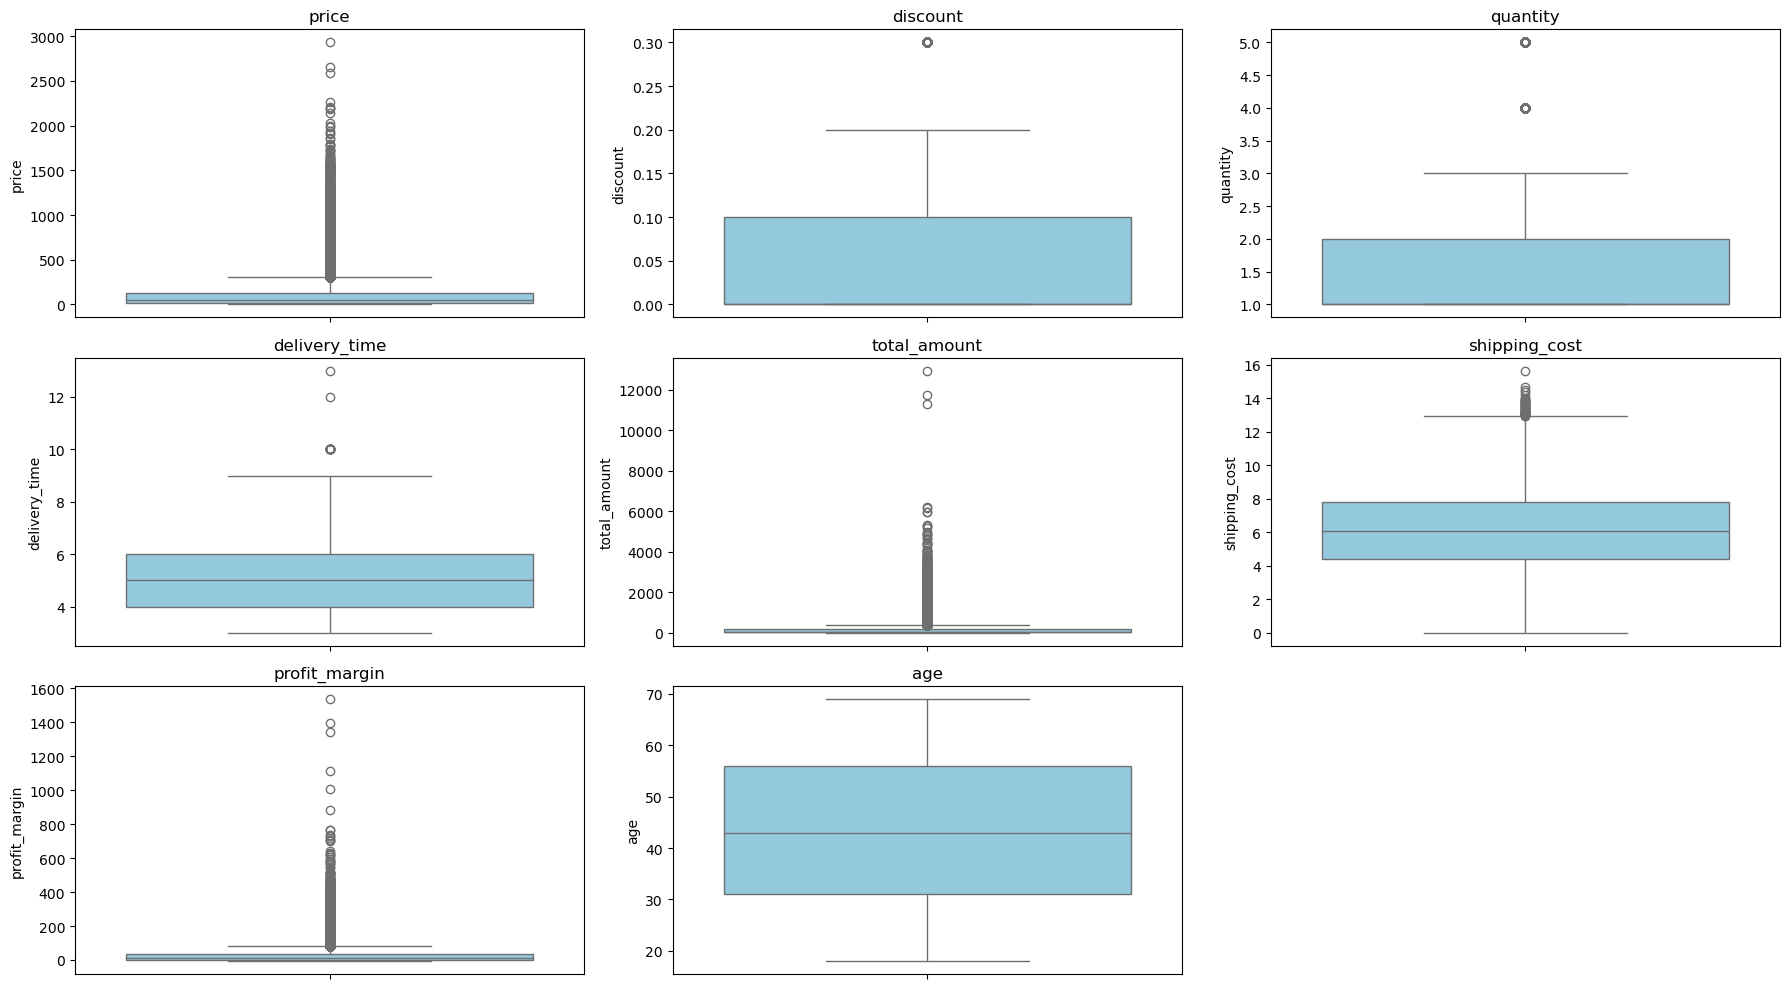

In [16]:
# Check outlier all numerical column

# Select numerical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

# Plot boxplots
plt.figure(figsize=(18,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot((len(num_cols)+2)//3, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(col)

plt.tight_layout()
plt.show()

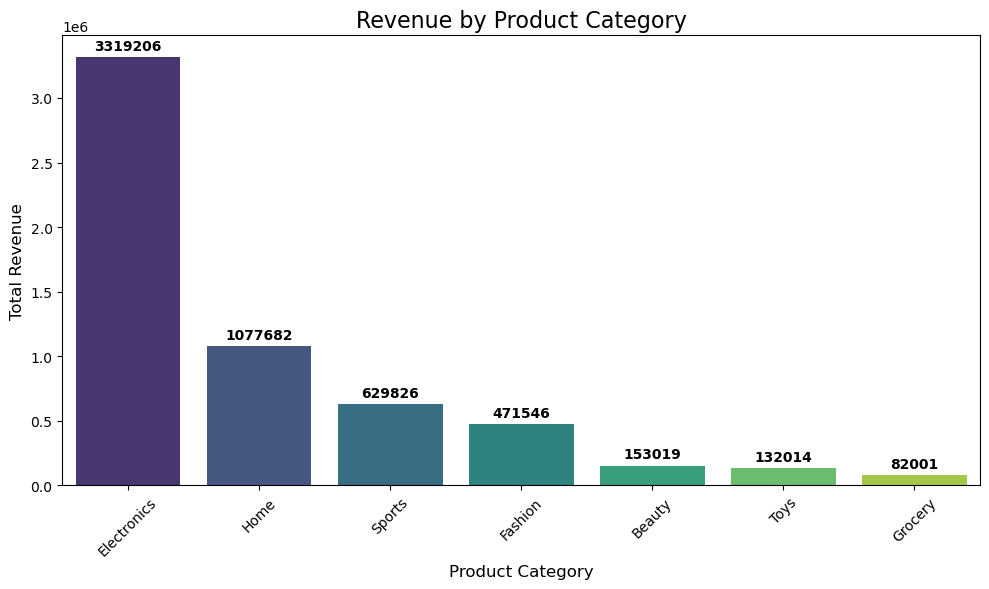

In [17]:
# 1. Which product categories generate the highest revenue?

# Group data by category
category_sales = (
    df.groupby("category", as_index=False)["total_amount"]
      .sum()
      .sort_values(by="total_amount", ascending=False)
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_sales,
    x="category",
    y="total_amount",
    hue="category",
    palette="viridis",
    legend=False
)

# Add total revenue labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',      # Display whole numbers
        padding=3,
        fontsize=10,
        fontweight='bold'
    )

plt.title("Revenue by Product Category", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 📈 1. Product Category Revenue

### 🔍 Insight
- Product categories contribute differently to total revenue.
- The highest revenue-generating category is the most profitable segment.
- Low-performing categories may require promotional campaigns or pricing improvements.

### 💡 Business Recommendation
- Increase inventory for high-performing categories.
- Offer discounts or bundle offers for low-performing categories.

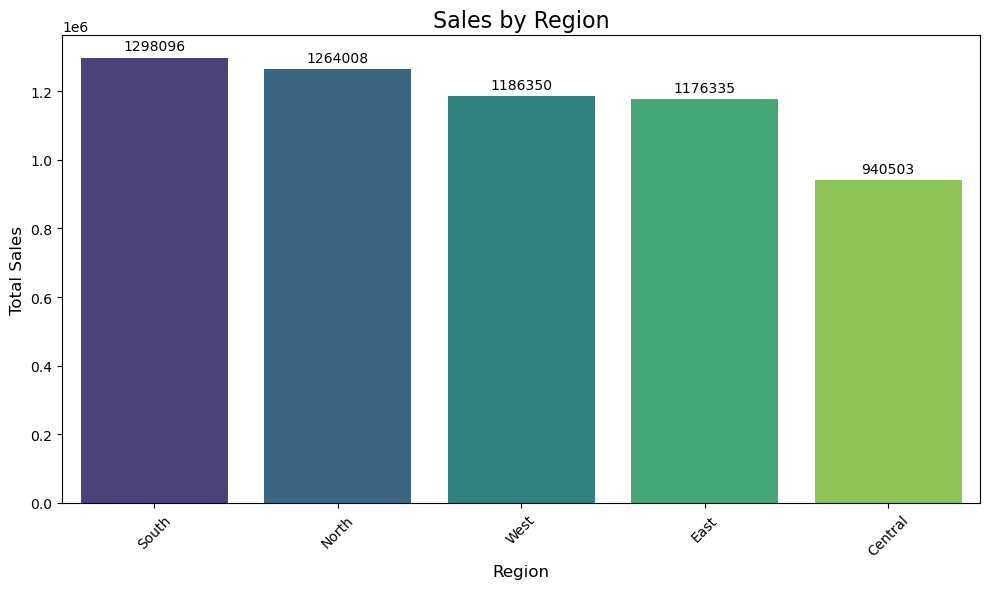

In [18]:
# 2. Calculate total sales by region
region_sales = (
    df.groupby("region", as_index=False)["total_amount"]
      .sum()
      .sort_values(by="total_amount", ascending=False)
)

# Plot
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=region_sales,
    x="region",
    y="total_amount",
    hue="region",
    palette="viridis",
    legend=False
)

# Add total sales labels on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.0f',
        padding=3,
        fontsize=10
    )

plt.title("Sales by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 🌍 2. Region-wise Sales Performance

### 🔍 Insight
- Sales vary across different regions.
- Some regions generate significantly higher revenue than others.

### 💡 Business Recommendation
- Focus marketing efforts on low-performing regions.
- Expand operations in high-performing regions.

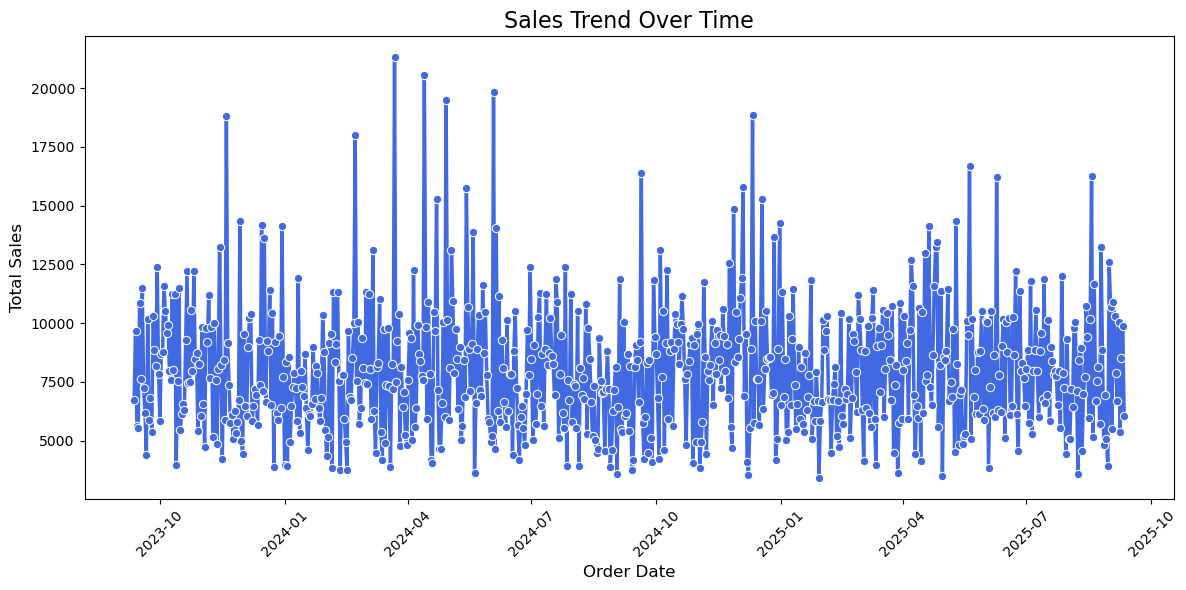

In [19]:
# 3. How does sales change over time?

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Calculate total sales by date
sales_trend = (
    df.groupby("order_date", as_index=False)["total_amount"]
      .sum()
      .sort_values("order_date")
)

# Create line chart
plt.figure(figsize=(12,6))

sns.lineplot(
    data=sales_trend,
    x="order_date",
    y="total_amount",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Sales Trend Over Time", fontsize=16)
plt.xlabel("Order Date", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 📅 3. Daily Sales Trend

### 🔍 Insight
- Daily sales fluctuate throughout the period.
- Peaks indicate high customer demand.

### 💡 Business Recommendation
- Maintain adequate inventory during peak sales days.
- Analyze reasons for sudden increases or decreases in sales.

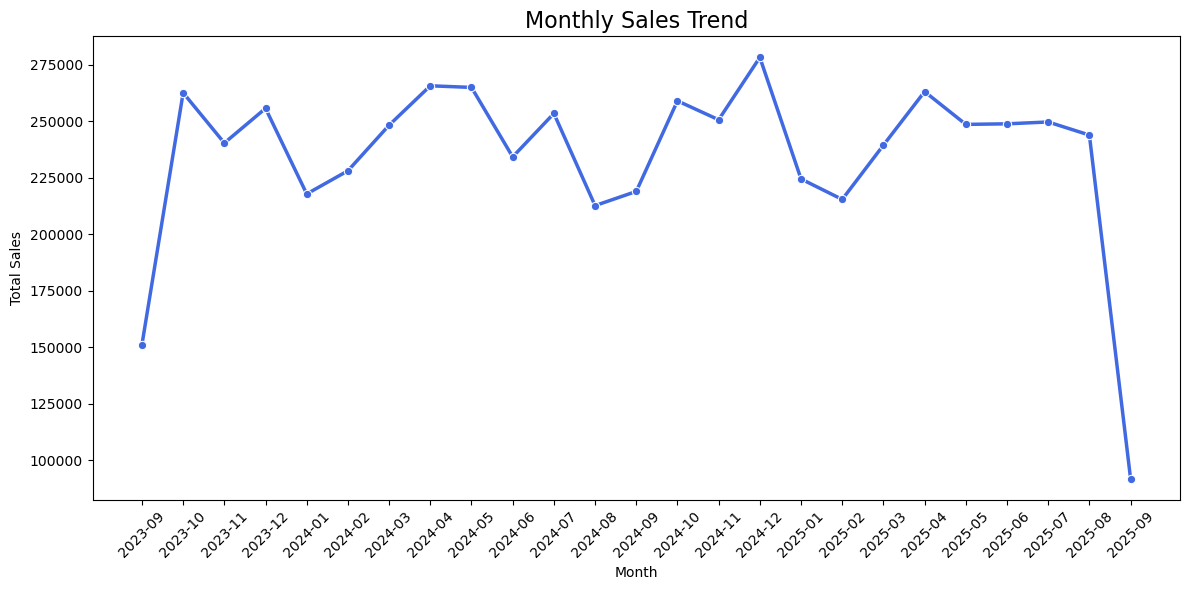

In [20]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Create Month-Year column
df["Month"] = df["order_date"].dt.to_period("M").astype(str)

# Monthly sales
monthly_sales = (
    df.groupby("Month", as_index=False)["total_amount"]
      .sum()
)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="total_amount",
    marker="o",
    linewidth=2.5,
    color="royalblue"
)

plt.title("Monthly Sales Trend", fontsize=16)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 📆  Monthly Sales Trend

### 🔍 Insight
- Monthly revenue helps identify seasonal demand.
- Certain months perform better than others.

### 💡 Business Recommendation
- Plan marketing campaigns before peak months.
- Prepare inventory according to seasonal demand.

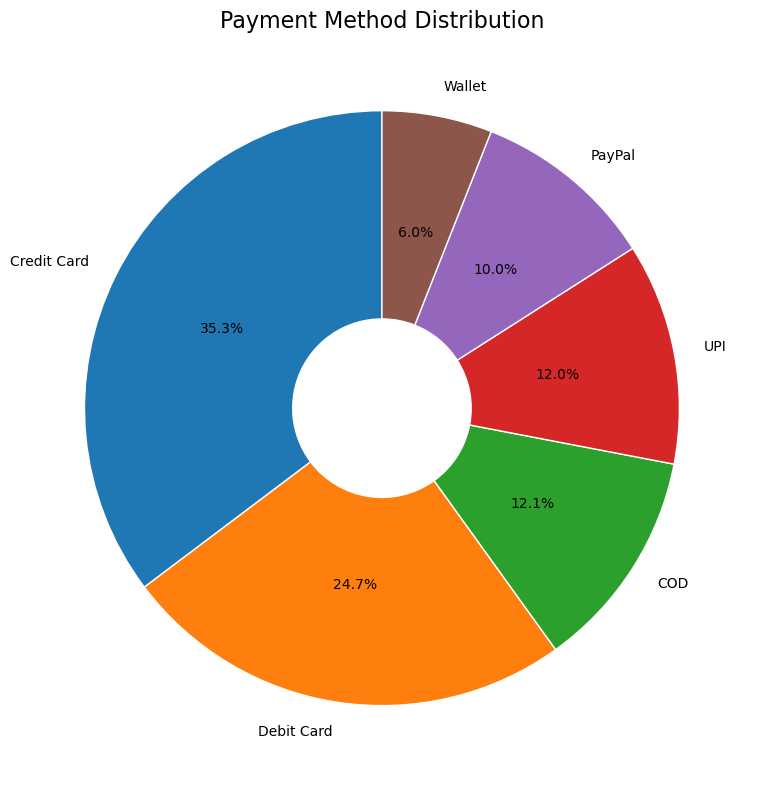

In [21]:
# 4. Which payment method is most popular?

# Count orders by payment method
payment_count = (
    df["payment_method"]
      .value_counts()
      .reset_index()
)

payment_count.columns = ["payment_method", "count"]

# Create Donut Chart
plt.figure(figsize=(8,8))

plt.pie(
    payment_count["count"],
    labels=payment_count["payment_method"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.7, "edgecolor":"white"}
)

plt.title("Payment Method Distribution", fontsize=16)

plt.tight_layout()
plt.show()

# 💳 4. Payment Method Analysis

### 🔍 Insight
- Customers prefer certain payment methods.
- Popular payment methods improve customer convenience.

### 💡 Business Recommendation
- Promote widely used payment options.
- Offer cashback or discounts on preferred payment methods.

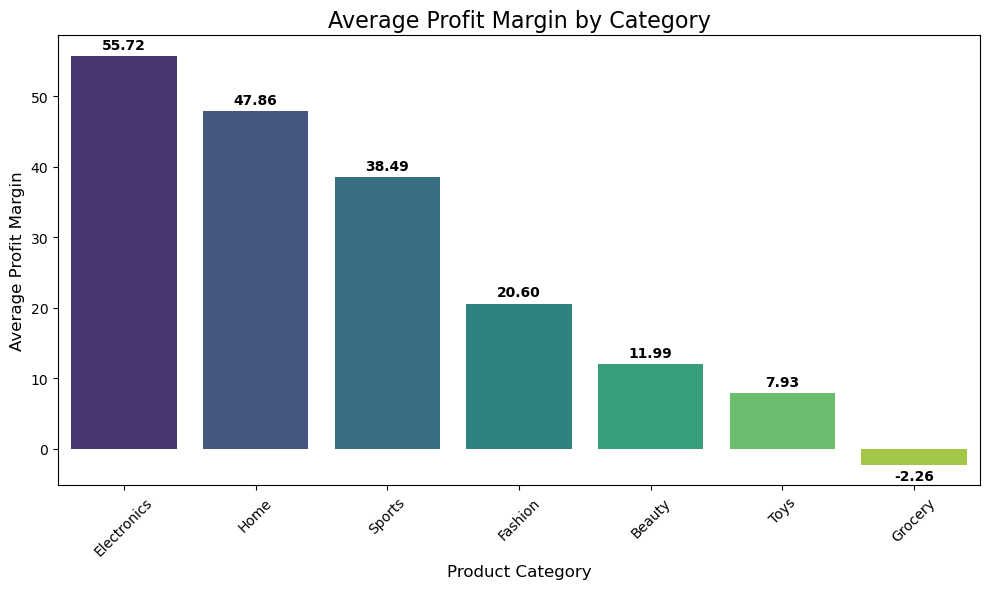

In [22]:
# 5. Which categories have the highest profit margin?

# Calculate average profit margin by category
category_profit = (
    df.groupby("category", as_index=False)["profit_margin"]
      .mean()
      .sort_values(by="profit_margin", ascending=False)
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_profit,
    x="category",
    y="profit_margin",
    hue="category",
    palette="viridis",
    legend=False
)

# Add profit margin labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title("Average Profit Margin by Category", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Average Profit Margin", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 💰 5. Profit Margin by Category

### 🔍 Insight
- High sales do not always result in high profit.
- Some categories have better profit margins than others.

### 💡 Business Recommendation
- Focus on products with higher profit margins.
- Review pricing strategy for low-profit categories.

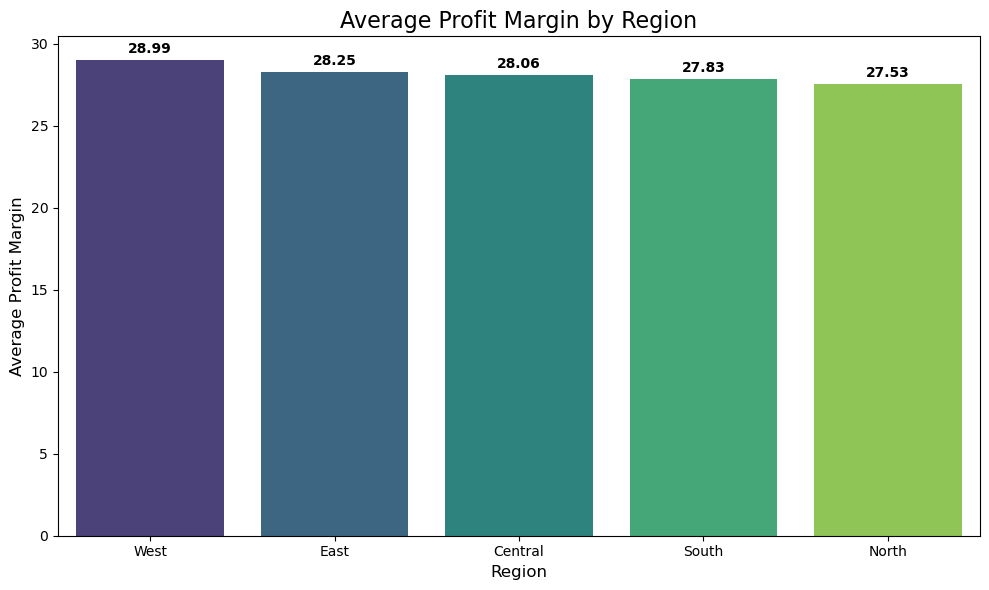

In [23]:
# 6. Which regions are the most profitable?

# Calculate average profit margin by region
region_profit = (
    df.groupby("region", as_index=False)["profit_margin"]
      .mean()
      .sort_values(by="profit_margin", ascending=False)
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=region_profit,
    x="region",
    y="profit_margin",
    hue="region",
    palette="viridis",
    legend=False
)

# Add value labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title("Average Profit Margin by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Average Profit Margin", fontsize=12)

plt.tight_layout()
plt.show()

# 📍 6. Profit Margin by Region

### 🔍 Insight
- Profitability differs across regions.
- Some regions have high sales but lower profit.

### 💡 Business Recommendation
- Reduce operational costs in low-profit regions.
- Optimize logistics and shipping expenses.

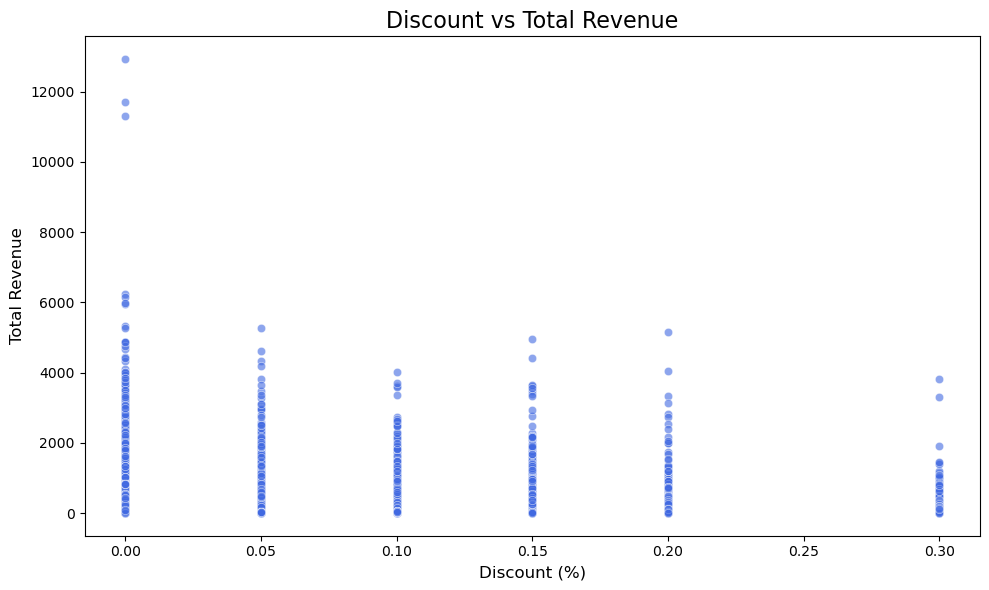

In [24]:
# 7. Does a higher discount increase revenue?

# Create Scatter Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount",
    y="total_amount",
    color="royalblue",
    alpha=0.6
)

plt.title("Discount vs Total Revenue", fontsize=16)
plt.xlabel("Discount (%)", fontsize=12)
plt.ylabel("Total Revenue", fontsize=12)

plt.tight_layout()
plt.show()

# 🎯 8. Discount vs Revenue

### 🔍 Insight
- Discounts influence customer purchases.
- Excessive discounts may not significantly increase revenue.

### 💡 Business Recommendation
- Identify the optimal discount percentage.
- Avoid unnecessary discount campaigns.

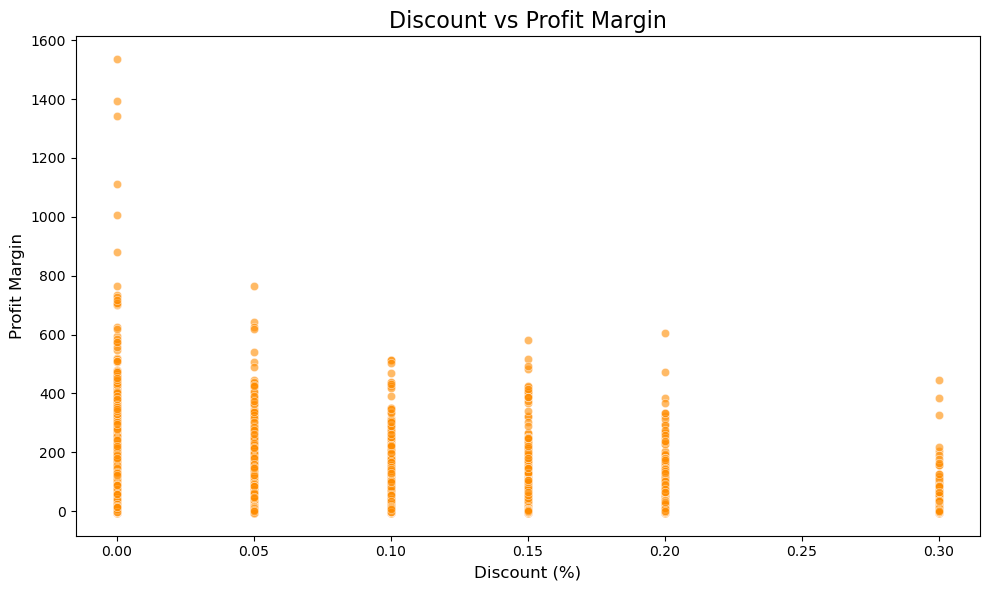

In [25]:
# 8. Does a higher discount reduce profit?

# Create Scatter Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount",
    y="profit_margin",
    color="darkorange",
    alpha=0.6
)

plt.title("Discount vs Profit Margin", fontsize=16)
plt.xlabel("Discount (%)", fontsize=12)
plt.ylabel("Profit Margin", fontsize=12)

plt.tight_layout()
plt.show()

# 📉 8. Discount vs Profit Margin

### 🔍 Insight
- Larger discounts generally reduce profit margins.

### 💡 Business Recommendation
- Balance discounts with profitability.
- Use targeted promotional offers instead of blanket discounts.

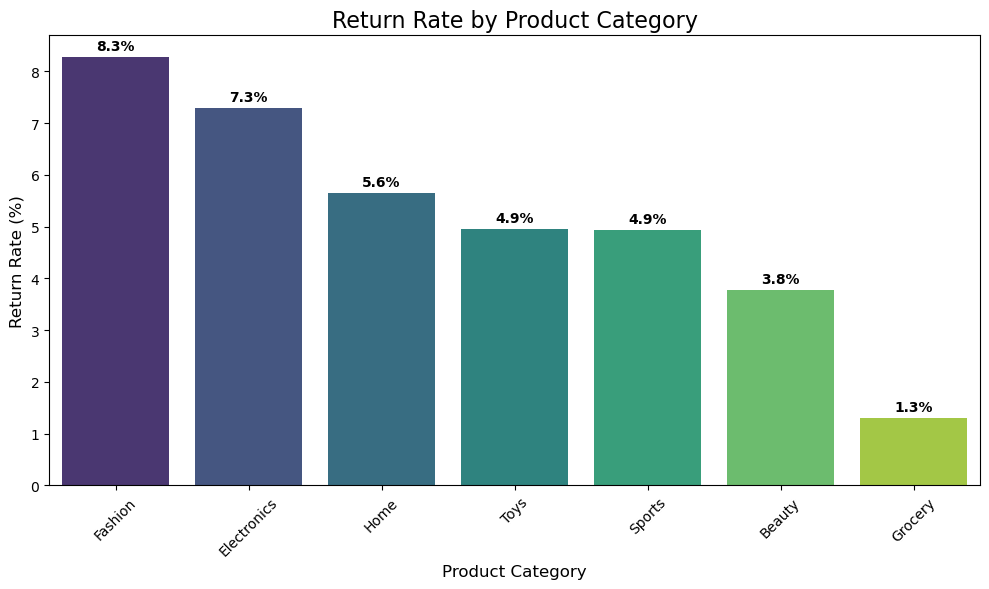

In [26]:
# 9. Which product categories have the highest return rate?

# Calculate return rate (%) by category
category_return = (
    df.groupby("category")["returned"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="return_rate")
      .sort_values(by="return_rate", ascending=False)
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=category_return,
    x="category",
    y="return_rate",
    hue="category",
    palette="viridis",
    legend=False
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )


plt.title("Return Rate by Product Category", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Return Rate (%)", fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 🔄 9. Return Rate by Category

### 🔍 Insight
- Some product categories have higher return rates.
- High returns may indicate quality or customer expectation issues.

### 💡 Business Recommendation
- Improve product descriptions.
- Conduct quality checks for high-return products.

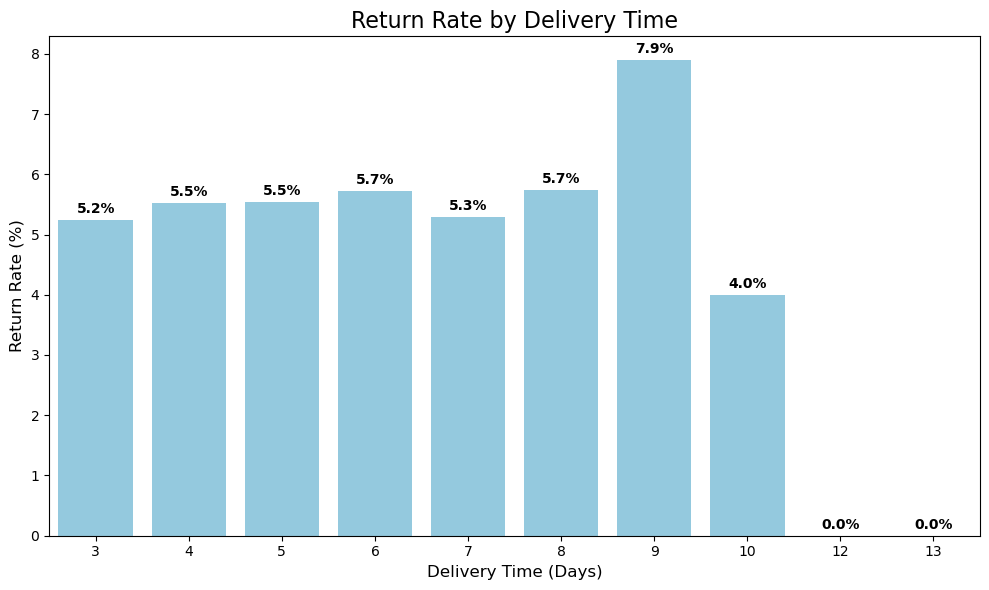

In [27]:
# 10. Does delivery time affect returns?

# Calculate return rate by delivery time
delivery_return = (
    df.groupby("delivery_time")["returned"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .reset_index(name="return_rate")
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=delivery_return,
    x="delivery_time",
    y="return_rate",
    color="skyblue"
)

# Add return rate labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=10,
        fontweight="bold"
    )

plt.title("Return Rate by Delivery Time", fontsize=16)
plt.xlabel("Delivery Time (Days)", fontsize=12)
plt.ylabel("Return Rate (%)", fontsize=12)

plt.tight_layout()
plt.show()

# 🚚 10. Delivery Time vs Returns

### 🔍 Insight
- Longer delivery times can increase product returns.

### 💡 Business Recommendation
- Improve delivery speed.
- Partner with reliable logistics providers.

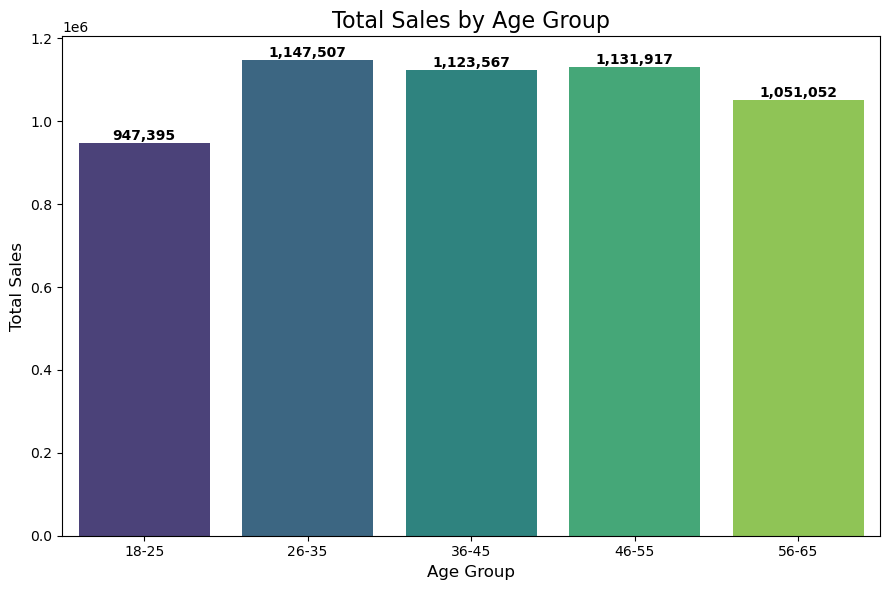

In [28]:
# 11. Which age group spends the most?

# Create age groups
df["age_group"] = pd.cut(
    df["age"],
    bins=[18, 25, 35, 45, 55, 65],
    labels=["18-25", "26-35", "36-45", "46-55", "56-65"],
    include_lowest=True
)

# Calculate total sales by age group
age_sales = (
    df.groupby("age_group", observed=False, as_index=False)["total_amount"]
      .sum()
)

# Create chart
plt.figure(figsize=(9,6))

ax = sns.barplot(
    data=age_sales,
    x="age_group",
    y="total_amount",
    hue="age_group",
    palette="viridis",
    legend=False
)

# Add value labels
for i, value in enumerate(age_sales["total_amount"]):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Total Sales by Age Group", fontsize=16)
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.tight_layout()
plt.show()

# 👥 11. Customer Age Group Analysis

### 🔍 Insight
- Spending behavior varies across age groups.
- Certain age groups contribute more revenue.

### 💡 Business Recommendation
- Create targeted marketing campaigns for high-value age groups.

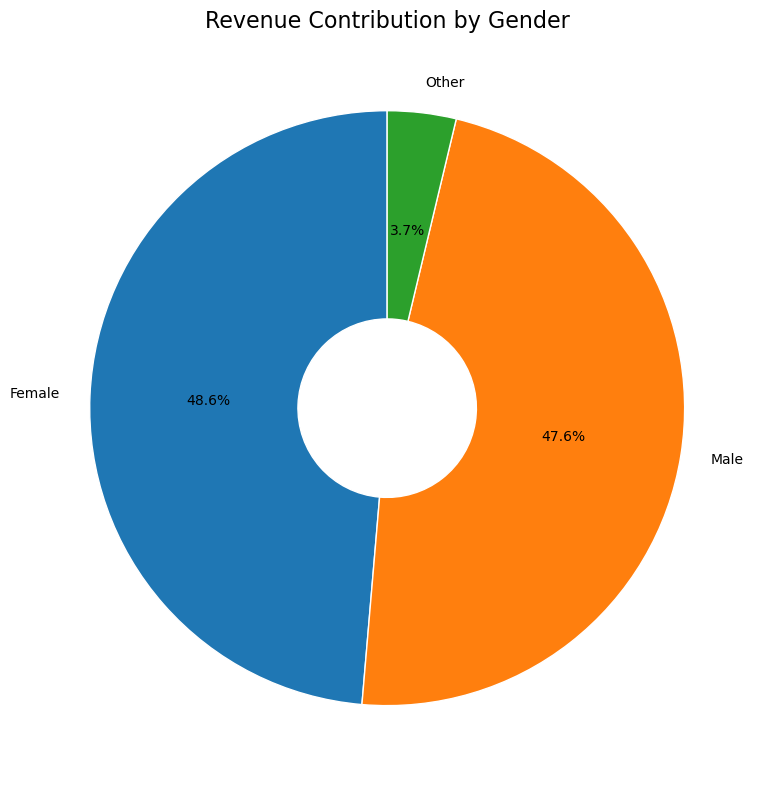

In [29]:
# 12. Which gender contributes more revenue?

# Calculate total revenue by gender
gender_sales = (
    df.groupby("gender", as_index=False)["total_amount"]
      .sum()
)

# Create Donut Chart
plt.figure(figsize=(8,8))

plt.pie(
    gender_sales["total_amount"],
    labels=gender_sales["gender"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.7, "edgecolor":"white"}
)

plt.title("Revenue Contribution by Gender", fontsize=16)

plt.tight_layout()
plt.show()

# 🚻 12. Revenue by Gender

### 🔍 Insight
- Purchasing behavior differs between genders.

### 💡 Business Recommendation
- Personalize product recommendations and advertisements.

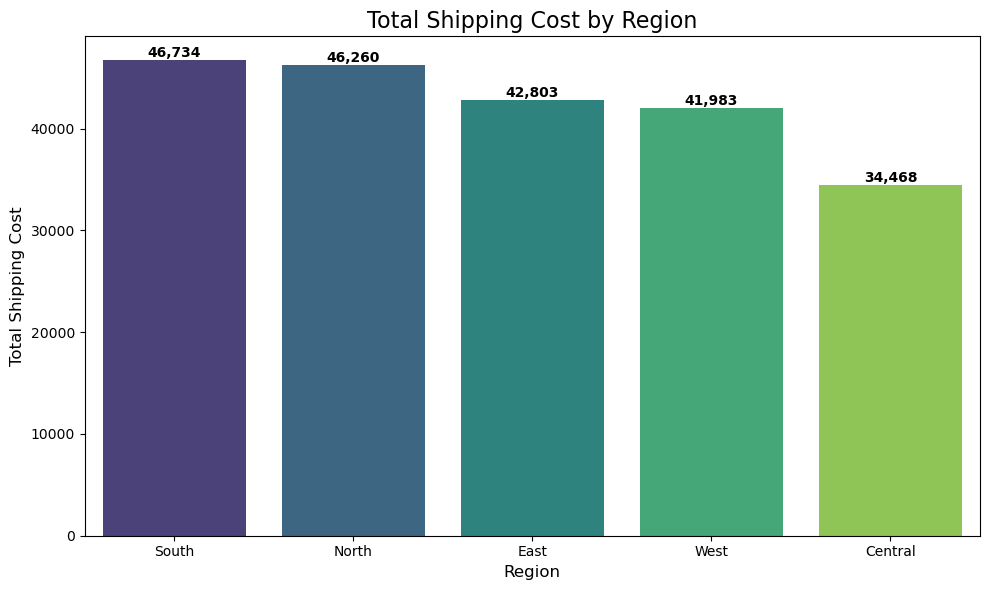

In [30]:
# 13. Which regions have the highest shipping costs?

# Calculate total shipping cost by region
region_shipping = (
    df.groupby("region", as_index=False)["shipping_cost"]
      .sum()
      .sort_values(by="shipping_cost", ascending=False)
)

# Create bar chart
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=region_shipping,
    x="region",
    y="shipping_cost",
    hue="region",
    palette="viridis",
    legend=False
)

# Add value labels
for i, value in enumerate(region_shipping["shipping_cost"]):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Total Shipping Cost by Region", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Shipping Cost", fontsize=12)

plt.tight_layout()
plt.show()

# 🚛 13. Shipping Cost Analysis

### 🔍 Insight
- Shipping costs vary by region.
- High shipping costs reduce profitability.

### 💡 Business Recommendation
- Optimize shipping routes.
- Negotiate better logistics pricing.

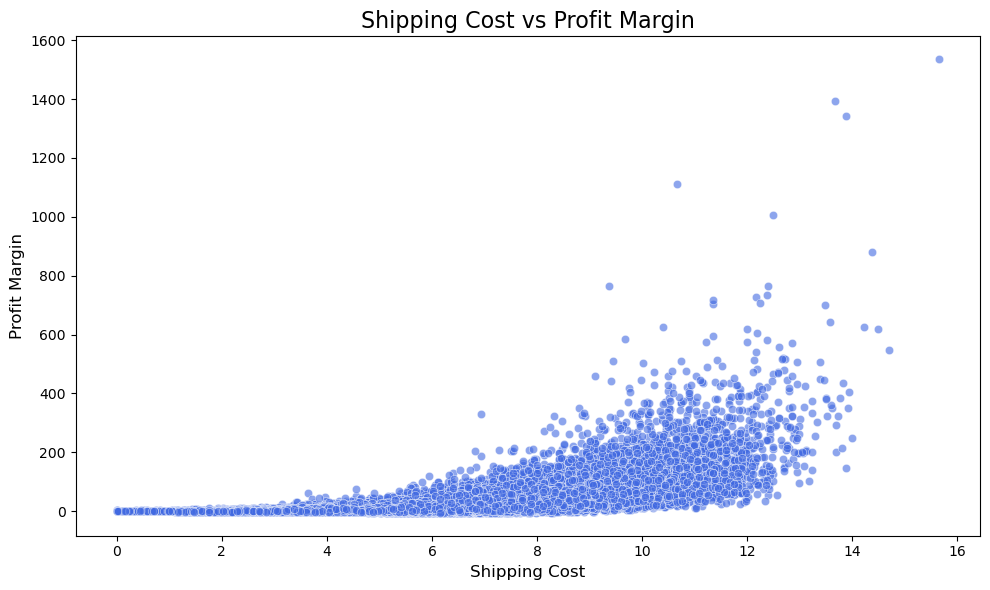

In [31]:
# 14. Does shipping cost affect profit?

# Create Scatter Plot
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="shipping_cost",
    y="profit_margin",
    color="royalblue",
    alpha=0.6
)

plt.title("Shipping Cost vs Profit Margin", fontsize=16)
plt.xlabel("Shipping Cost", fontsize=12)
plt.ylabel("Profit Margin", fontsize=12)

plt.tight_layout()
plt.show()

# 📦 14. Shipping Cost vs Profit

### 🔍 Insight
- Increased shipping costs reduce overall profit margins.

### 💡 Business Recommendation
- Monitor shipping expenses regularly.
- Consider free shipping only for high-value orders.

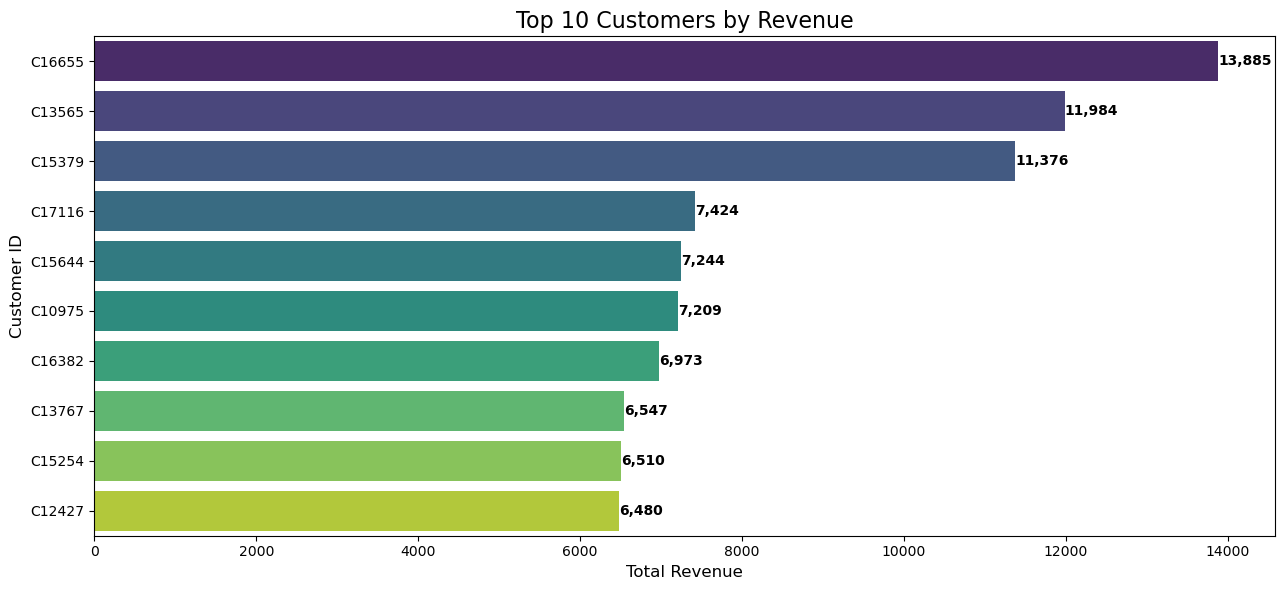

In [32]:
# 15. Which customers generate the highest revenue?

# Calculate total revenue by customer
top_customers = (
    df.groupby("customer_id", as_index=False)["total_amount"]
      .sum()
      .sort_values(by="total_amount", ascending=False)
      .head(10)
)

# Create horizontal bar chart
plt.figure(figsize=(13,6))

ax = sns.barplot(
    data=top_customers,
    x="total_amount",
    y="customer_id",
    hue="customer_id",
    palette="viridis",
    legend=False
)

# Add revenue labels
for i, value in enumerate(top_customers["total_amount"]):
    ax.text(
        value,
        i,
        f"{value:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Top 10 Customers by Revenue", fontsize=16)
plt.xlabel("Total Revenue", fontsize=12)
plt.ylabel("Customer ID", fontsize=12)

plt.tight_layout()
plt.show()

# 👑 15. Top Customers

### 🔍 Insight
- A small group of customers contributes a large portion of total revenue.

### 💡 Business Recommendation
- Launch loyalty and reward programs.
- Provide exclusive offers for premium customers.

In [33]:
df.to_csv("Cleaned_E_Commerce_Sale.csv", index =False)